## About Dataset
___
This dataset opens the door to the intricacies of the 2023 NBA season, offering a profound understanding of the art of scoring in professional basketball. Within its comprehensive analysis, it showcases the remarkable prowess of 3 players LeBron James, James Harden, and Stephen Curry—true icons of the sport. Delve deep into the strategic brilliance that defines these players' shooting trends, performance metrics, and unwavering precision on the court. Whether you're a passionate basketball enthusiast or a data-driven analyst, this dataset provides a unique and invaluable window into the mastery of these legendary athletes and the ever-evolving game of basketball.

### Steph Curry Shot Dataset

| Dataset Columns | Description |
| --- | --- |
| **top** | The vertical position on the court where the shot was taken. |
| **left** | The horizontal position on the court where the shot was taken. |
| **date** | The date when the shot was taken (e.g., Oct 18, 2022). |
| **qtr** | The quarter of the attempt (e.g., "1st Qtr", "2nd Qtr"). |
| **time_remaining** | Time remaining in the quarter (e.g., 09:26). |
| **result** | Success of the shot: **TRUE** (made) or **FALSE** (missed). |
| **shot_type** | Type of shot: **2** (two-pointer) or **3** (three-pointer). |
| **distance_ft** | Distance in feet from the hoop to the shot location. |
| **lead** | **TRUE** if Curry's team was leading, **FALSE** otherwise. |
| **player_team_score** | Steph Curry's team's score at the time of the shot. |
| **opponent_team_score** | The opposing team's score at the time of the shot. |
| **opponent** | Abbreviation for the opposing team (e.g., LAL). |
| **team** | Abbreviation for Steph Curry's team (e.g., GSW). |
| **season** | The season year (e.g., 2023). |
| **color** | Color code (e.g., "red" or "green") for visual shot mapping. |

---

### How to use this dataset

Data Scientists and Analysts: Employ advanced statistical analysis to uncover hidden patterns and insights in the shooting trends of LeBron James, James Harden, and Stephen Curry.

## Purpose of this report is analyzing the statistics for Stepy Curry

## The Dataset

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

# Torna src/ importável independente de onde o kernel foi iniciado
ROOT = Path('../').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy import stats

from src.constants import DATA_DIR, DATA_FILE_NAME
from src.data_downloader import DataDownloader
from src.logger import get_logger, setup_logger

import warnings
from src.constants import ALPHA

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Configurações gerais ---
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# --- Estilo dos gráficos ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [3]:
setup_logger(level='INFO')
log = get_logger(__name__)

In [4]:
data_path = DATA_DIR / DATA_FILE_NAME

if data_path.exists():
    log.info('Carregando dados do cache local')
    df = pd.read_csv(data_path)
else:
    log.info('Arquivo nao encontrado - iniciando download')
    df = DataDownloader().download()

15:39:25 | INFO     | __main__:4 - Carregando dados do cache local


In [5]:
print(f'Shape: {df.shape}')
df.head()

Shape: (1434, 15)


,top,left,date,qtr,time_remaining,result,shot_type,distance_ft,lead,player_team_score,opponent_team_score,opponent,team,season,color
0,63,300,"Oct 18, 2022",1st Qtr,7:27,False,2,6,True,9,6,LAL,GSW,2023,red
1,133,389,"Oct 18, 2022",1st Qtr,7:22,True,2,17,True,11,6,LAL,GSW,2023,green
2,326,247,"Oct 18, 2022",1st Qtr,7:11,False,3,27,True,11,6,LAL,GSW,2023,red
3,249,89,"Oct 18, 2022",1st Qtr,5:16,False,3,25,True,19,13,LAL,GSW,2023,red
4,282,158,"Oct 18, 2022",1st Qtr,3:52,False,3,24,True,22,17,LAL,GSW,2023,red


In [6]:
def describe_dataframe(df: pd.DataFrame) -> pd.DataFrame.style:
    """Gera um resumo estrutural do DataFrame com estilo visual.

    Retorna uma tabela estilizada com tipo, contagem de valores não-nulos
    e percentual de dados faltantes por coluna.

    Args:
        df: DataFrame a ser descrito.

    Returns:
        pd.DataFrame.style: Tabela estilizada com header destacado.
    """
    # Corrige Sleep Disorder: 'None' string não é dado faltante
    df = df.copy()

    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "non_null_count": df.notna().sum(),
        "null_count": df.isna().sum(),
        "missing_pct": (df.isna().sum() / len(df) * 100).round(2),
    }).sort_values("missing_pct", ascending=False)

    return (
        summary.style
        .set_table_styles([{
            "selector": "thead th",
            "props": [
                ("background-color", "#2c7bb6"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("font-size", "13px"),
                ("padding", "8px"),
            ]
        }])
        .format({"missing_pct": "{:.2f}%"})
    )

In [7]:
describe_dataframe(df)

,dtype,non_null_count,null_count,missing_pct
top,int64,1434,0,0.00%
left,int64,1434,0,0.00%
date,str,1434,0,0.00%
qtr,str,1434,0,0.00%
time_remaining,str,1434,0,0.00%
result,bool,1434,0,0.00%
shot_type,int64,1434,0,0.00%
distance_ft,int64,1434,0,0.00%
lead,bool,1434,0,0.00%
player_team_score,int64,1434,0,0.00%


## Review

# A. Probabilidade Teórica (O Mundo Ideal)

Na teoria, assumimos que o dado é honesto. Como existem 6 faces, a probabilidade de qualquer face sair é exatamente $1/6$.


In [8]:
# Probabilidade Teórica em Python
lados_do_dado = 6
probabilidade_teorica = 1 / lados_do_dado

print(f"Probabilidade Teórica de tirar um 5: {probabilidade_teorica:.4f} (ou {probabilidade_teorica*100:.2f}%)")

Probabilidade Teórica de tirar um 5: 0.1667 (ou 16.67%)


# B. Probabilidade Empírica (O mundo real)
A probabilidade empírica é baseada na observação. Nós jogamos o dado $N$ vezes e contamos quantas vezes o resultado que queríamos apareceu.Aqui está um script que simula o lançamento de um dado e calcula a probabilidade baseada nos resultados obtidos:

In [9]:
import random

def calcular_probabilidade_empirica(tentativas):
    resultados = [random.randint(1, 6) for _ in range(tentativas)]

    # Vamos contar quantas vezes o número 5 apareceu
    sucessos = resultados.count(5)
    probabilidade_empirica = sucessos / tentativas

    return probabilidade_empirica

# Exemplo com 10 lançamentos
p_10 = calcular_probabilidade_empirica(10)
print(f"Empírica (10 jogadas): {p_10:.4f}")

# Exemplo com 100.000 lançamentos
p_100k = calcular_probabilidade_empirica(100000)
print(f"Empírica (100.000 jogadas): {p_100k:.4f}")

Empírica (10 jogadas): 0.1000
Empírica (100.000 jogadas): 0.1678


A tabela abaixo resume a diferença aplicada ao nosso código:

| Conceito | Como o Python calcula | Resultado Esperado |
| --- | --- | --- |
| **Teórica** | `1 / 6` | Sempre `0.1666...` |
| **Empírica** | `count(x) / len(lista)` | Varia a cada execução (ex: `0.14`, `0.18`, etc.) |

### Por que os números mudam?

Se você rodar o código acima com apenas 10 tentativas, a probabilidade empírica pode ser `0.0` (se o 5 nunca sair) ou `0.3` (se sair 3 vezes). Isso é a **variância**. Conforme aumentamos o número de tentativas para 100.000, o Python mostrará um valor muito próximo de `0.1666`, provando que a prática converge para a teoria.

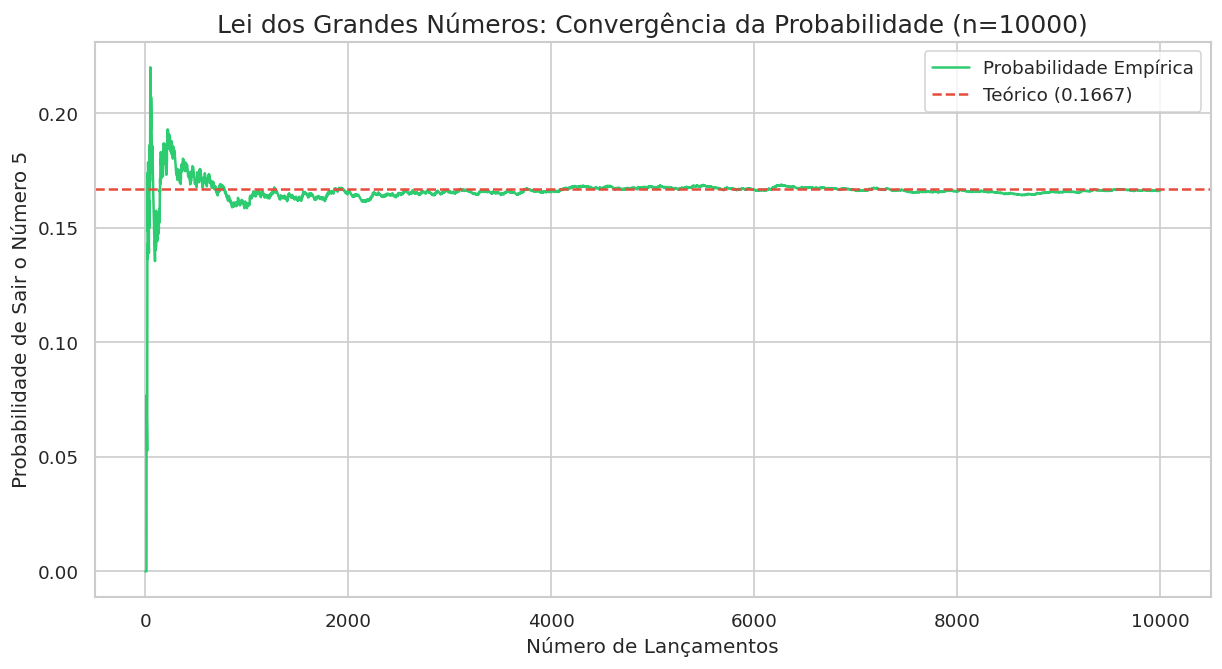

In [10]:
# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

def simular_convergencia(n_tentativas):
    # Simula n lançamentos de um dado (1 a 6)
    lancamentos = np.random.randint(1, 7, size=n_tentativas)

    # Verifica onde o resultado foi igual a 5 (gera um array de booleanos)
    sucessos = (lancamentos == 5)

    # Calcula a média acumulada (probabilidade empírica evolutiva)
    # Ex: [True, False, True] -> [1, 1, 2] -> [1/1, 1/2, 2/3]
    probabilidades_passo_a_passo = np.cumsum(sucessos) / np.arange(1, n_tentativas + 1)

    return probabilidades_passo_a_passo

# Parâmetros
n = 10000
tentativas_eixo_x = np.arange(1, n + 1)
probabilidades_y = simular_convergencia(n)
valor_teorico = 1/6

# Criação do Gráfico
plt.figure(figsize=(12, 6))
plt.plot(tentativas_eixo_x, probabilidades_y, label='Probabilidade Empírica', color='#2ecc71')
plt.axhline(y=valor_teorico, color='#e74c3c', linestyle='--', label=f'Teórico ({valor_teorico:.4f})')

# Ajustes de layout
plt.title(f'Lei dos Grandes Números: Convergência da Probabilidade (n={n})', fontsize=15)
plt.xlabel('Número de Lançamentos', fontsize=12)
plt.ylabel('Probabilidade de Sair o Número 5', fontsize=12)
plt.legend()
plt.show()

Exatamente! Você descreveu perfeitamente a **Lei dos Grandes Números**. À medida que o número de experimentos ($n$) cresce, a frequência relativa dos eventos observados converge para a probabilidade teórica.

No limite, quando $n \to \infty$, a diferença entre a média observada e o valor esperado tende a zero.

---

## 2. O que este gráfico nos ensina?

1. **Instabilidade Inicial:** No começo (lado esquerdo do gráfico), a linha oscila bruscamente. Se você jogar o dado 5 vezes e o número "5" sair 2 vezes, sua probabilidade empírica será de $40\%$ ($0,4$), muito longe da teoria.
2. **O "Efeito Amortecedor":** Conforme o número de lançamentos aumenta, cada novo resultado individual tem menos peso sobre a média total.
3. **Convergência:** Eventualmente, a linha "gruda" na linha pontilhada vermelha (teórica). Isso mostra que o acaso se torna previsível quando observado em larga escala.

### Resumo Técnico

* **Probabilidade Empírica:** $\hat{P}(E) = \frac{n_E}{n}$
* **Lei dos Grandes Números:** $\lim_{n \to \infty} \hat{P}(E) = P(E)$

> **Cuidado com a "Falácia do Apostador":** A Lei dos Grandes Números diz que a média se ajusta no longo prazo, mas ela não "força" um resultado para compensar os anteriores. O dado não tem memória; cada jogada continua sendo $1/6$.

Entendi perfeitamente! O que você está lembrando é um dos "truques" mais elegantes do Pandas e do NumPy para lidar com dados booleanos.

Em computação, o valor `True` é tratado como **1** e o `False` como **0**. Isso permite que você use funções matemáticas diretamente em colunas de booleanos para obter estatísticas rápidas.

---

### 3. O "Truque" da Média (`.mean()`)

Quando você tira a média de uma coluna booleana, o resultado é a **proporção de True** (ou seja, a Probabilidade Empírica).

Se você tem 10 linhas e 3 são `True`:


$$\text{Média} = \frac{1+1+1+0+0+0+0+0+0+0}{10} = 0.3 \text{ (ou 30\%)}$$

In [11]:
# Criando um DF de exemplo
df_1 = pd.DataFrame({'result': [True, False, True, True, False]})

# A probabilidade empírica (proporção de Trues)
probabilidade = df_1['result'].mean()

print(f"Proporção de True: {probabilidade:.2f}") 
# Resultado: 0.60 (pois 3 de 5 são True)

Proporção de True: 0.60


### 4. O Total de Trues (`.sum()`)

Se você quer apenas o **total (contagem)** de eventos verdadeiros, basta usar o `.sum()`. Como cada `True` vale 1, a soma de todos eles será exatamente a quantidade de vezes que o evento ocorreu.

```python
# Contagem total de Trues
total_trues = df['result'].sum()

print(f"Total de eventos True: {total_trues}")
# Resultado: 3

```


### Por que isso é melhor que selecionar e contar?

Fazer `df[df['result'] == True].count()` funciona, mas é mais lento e verboso. O `.sum()` e o `.mean()` em colunas booleanas são operações vetorizadas extremamente rápidas.

---

### 5. Resumo Visual das Operações

| Objetivo | Comando Pandas | Equivalente Estatístico |
| --- | --- | --- |
| **Contagem de Sucessos** | `df['col'].sum()` | Frequência Absoluta |
| **Proporção / Probabilidade** | `df['col'].mean()` | Frequência Relativa ($P$ empírica) |

--

### 6. Exemplo Aplicado ao Dado

Vamos unir tudo: jogamos um dado e queremos saber a probabilidade empírica de sair um número maior que 4.

**Ficou claro como a média e a soma funcionam com booleanos? Quer que eu te mostre como agrupar isso por outra categoria usando o `.groupby()`?**

In [12]:
import numpy as np

# Simulando 1000 jogadas
jogadas = np.random.randint(1, 7, size=1000)
df_dados = pd.DataFrame({'valor': jogadas})

# Criando a coluna booleana 'result' (True se > 4)
df_dados['result'] = df_dados['valor'] > 4

# Calculando com os métodos que você lembrou:
total_sucessos = df_dados['result'].sum()
probabilidade_empirica = df_dados['result'].mean()

print(f"Total de vezes que saiu > 4: {total_sucessos}")
print(f"Probabilidade Empírica: {probabilidade_empirica:.4f}")
print(f"Probabilidade Teórica (5 e 6): {2/6:.4f}")

Total de vezes que saiu > 4: 354
Probabilidade Empírica: 0.3540
Probabilidade Teórica (5 e 6): 0.3333


Para identificar se uma questão trata de **Probabilidade Binomial**, você deve procurar por quatro características específicas (o famoso acrônimo **BINS** em inglês). Se o problema passar nesse "check-list", ele é binomial.

## 7. Como Identificar (Critérios BINS)

1. **B - Binário:** O resultado só pode ter dois caminhos: **Sucesso** ou **Fracasso** (Ex: Cara/Coroa, Peça Defeituosa/Não Defeituosa, Ganhar/Perder).
2. **I - Independência:** O resultado de uma tentativa não afeta a próxima (Ex: O dado não tem memória).
3. **N - Número Fixo ($n$):** A questão define exatamente quantas vezes o experimento será repetido (Ex: Jogar a moeda 10 vezes).
4. **S - Sucesso Constante ($p$):** A probabilidade de sucesso é a mesma em todas as tentativas.

A fórmula matemática que descreve isso é:


$$P(X = k) = \binom{n}{k} \cdot p^k \cdot (1-p)^{n-k}$$

Onde:

* $n$: número total de tentativas.
* $k$: número de sucessos desejados.
* $p$: probabilidade de sucesso em uma tentativa.

---

## 7.1 Exemplos Práticos com Python

Para trabalhar com isso em Python, utilizamos a biblioteca `scipy.stats`, especificamente a função `binom`.

### Exemplo 1: Lançamento de Moedas (O Clássico)

**Problema:** Se você lançar uma moeda honesta 10 vezes, qual a probabilidade exata de obter "Cara" exatamente 6 vezes?

```python
from scipy.stats import binom

# Parâmetros
n = 10      # total de lançamentos
p = 0.5     # chance de cara (50%)
k = 6       # sucessos desejados

# pmf = Probability Mass Function (Probabilidade Exata)
prob_exata = binom.pmf(k, n, p)

print(f"A probabilidade de 6 caras em 10 lançamentos é: {prob_exata:.4f}")

```

---

### Exemplo 7.2: Controle de Qualidade (O Aplicado)

**Problema:** Uma fábrica produz lâmpadas e sabe-se que 5% delas são defeituosas. Se pegarmos uma amostra aleatória de 20 lâmpadas, qual a probabilidade de encontrarmos **no máximo 2** defeituosas?

*Nota: "No máximo 2" significa a soma das probabilidades de 0, 1 e 2 defeitos.*

```python
from scipy.stats import binom

# Parâmetros
n = 20      # tamanho da amostra
p = 0.05    # chance de defeito (5%)
k = 2       # limite de sucessos

# cdf = Cumulative Distribution Function (Probabilidade Acumulada de 0 até k)
prob_acumulada = binom.cdf(k, n, p)

print(f"A probabilidade de ter no máximo 2 lâmpadas defeituosas é: {prob_acumulada:.4f}")

```

---

### 7.3. Resumo Visual: PMF vs CDF

| Função | O que faz? | Exemplo de Pergunta |
| --- | --- | --- |
| **`pmf(k, n, p)`** | Probabilidade **Exata** | "Qual a chance de tirar **exatamente** 3?" |
| **`cdf(k, n, p)`** | Probabilidade **Acumulada** | "Qual a chance de tirar **até** 3?" |

---

## Section 1 - Overall Shooting Statistics
___

The concept here is **empirical probability**: instead of a theoretical model, we estimate probability directly from observed data.

## Dataset Overview

- **Total shots:** 1,434
- **No missing values** — data is clean and ready for analysis

### Key columns for this project

| Column | Type | Description |
|---|---|---|
| `result` | bool | True = make, False = miss |
| `shot_type` | int | 2 or 3 pointer |
| `lead` | bool | True = team was leading when shot was taken |

---

## Concept: Empirical Probability

Instead of a theoretical model, we estimate probability directly from observed data:

$$P(A) = \frac{\text{count of event A}}{\text{total observations}}$$

---

## Your Task

Calculate and store these four values as variables — they will be the **building blocks** for every calculation in the rest of the project:

1. $P(\text{make})$ — proportion of `result == True`
2. $P(\text{miss})$ — complement: $1 - P(\text{make})$
3. $P(\text{3-pointer})$ — proportion of `shot\_type == 3`
4. $P(\text{2-pointer})$ — proportion of `shot\_type == 2`

---

## Python Hint

```python
total = len(df)

p_make = ...
p_miss = ...
p_three = ...
p_two = ...
```

> Store these as variables — you will reuse them constantly in Sections 2, 3, and 4.

In [22]:
print(df.dtypes)

top                    int64
left                   int64
date                     str
qtr                      str
time_remaining           str
result                  bool
shot_type              int64
distance_ft            int64
lead                    bool
player_team_score      int64
opponent_team_score    int64
opponent                 str
team                     str
season                 int64
color                    str
dtype: object


In [14]:
print(df['result'].dtype)
print(df['result'].value_counts())

bool
result
False    731
True     703
Name: count, dtype: int64


In [15]:
total = df.shape[0]
print(f"Total de registros: {total}")

Total de registros: 1434


In [16]:
# Count of success: p_make
p_make = df['result'].sum() / total
print(f"Probability of success (True): {p_make}")

Probability of success (True): 0.4902370990237099


In [17]:
# Count of miss: p_miss
p_miss = 1 - p_make
print(f"Probability of miss (False): {p_miss}")

Probability of miss (False): 0.5097629009762901


In [20]:
# Count of 2s and 3 type-shots: count_two and count_three
count_shot_type = df['result'].groupby(df['shot_type']).count() 
print(f"Count of 2 shot-type 2: {count_shot_type[2]}")
print(f"Count of 3 shot-type 3: {count_shot_type[3]}")

Count of 2 shot-type 2: 648
Count of 3 shot-type 3: 786


In [21]:
p_two = count_shot_type[2] / total
p_three = count_shot_type[3] / total
print(f"Probability of shot-type 2: {p_two:.4f}")
print(f"Probability of shot-type 3: {p_three:.4f}")

Probability of shot-type 2: 0.4519
Probability of shot-type 3: 0.5481


In [23]:
print("=" * 45)
print(f"{'OVERALL SHOOTING STATISTICS':^45}")
print("=" * 45)
print(f"{'Metric':<30} {'Probability':>10}")
print("-" * 45)
print(f"{'P(Make)':<30} {p_make:>10.4f}")
print(f"{'P(Miss)':<30} {p_miss:>10.4f}")
print(f"{'P(Three-pointer)':<30} {p_three:>10.4f}")
print(f"{'P(Two-pointer)':<30} {p_two:>10.4f}")
print("=" * 45)

         OVERALL SHOOTING STATISTICS         
Metric                         Probability
---------------------------------------------
P(Make)                            0.4902
P(Miss)                            0.5098
P(Three-pointer)                   0.5481
P(Two-pointer)                     0.4519


# Section 2 — Probabilities

## Questions to Answer

1. What is the probability of Steph **making 3 of the next 4 shots**?
2. What is the probability that **4 of the next 5 shots are three-pointers**?

---

## Concept: Binomial Probability

Both questions follow the same pattern — a fixed number of independent trials,
each with the same probability of success. This is the **Binomial Distribution**:

$$P(X = k) = \binom{n}{k} \cdot p^k \cdot (1-p)^{n-k}$$

Where:
- $n$ = total number of trials (shots)
- $k$ = number of successes we want
- $p$ = probability of success on a single trial
- $\binom{n}{k}$ = number of ways to choose $k$ successes from $n$ trials

---

# Section 2 — Probabilities

## Questions to Answer

1. What is the probability of Steph **making 3 of the next 4 shots**?

   > **Clarification:** There is only one scenario here — exactly 3 makes out of 4 shots.
   > The binomial formula already accounts for all different orderings
   > (e.g. make-make-make-miss, make-make-miss-make, etc.) through the $\binom{n}{k}$ term.
   > So no need to split into sub-cases!

2. What is the probability that **4 of the next 5 shots are three-pointers**?

   > **Clarification:** This is about **shot type**, not about whether the shot goes in.
   > The question asks: out of 5 shots, how many are *three-point attempts*?
   > So use $p = p\_three$, $k = 4$, $n = 5$ — don't mix up shot type with shot result!

---

## Mapping to Our Problem

| | Question 1 | Question 2 |
|---|---|---|
| $n$ | 4 shots | 5 shots |
| $k$ | 3 makes | 4 three-pointers |
| $p$ | `p_make` | `p_three` |

---

## Key Assumption

> **Both questions assume the shots are independent** — the outcome of one shot
> does not affect the probability of the next one.

This is an important assumption to state explicitly in your presentation,
as it may not perfectly reflect reality (fatigue, momentum, defense adjustments, etc.)

---

## Python Hint

```python
from math import comb

# P(exactly k successes in n trials)
def binomial_prob(n, k, p):
    return comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

# Question 1: P(3 makes in 4 shots)
p_q1 = binomial_prob(n=4, k=3, p=p_make)

# Question 2: P(4 three-pointers in 5 shots)
p_q2 = binomial_prob(n=5, k=4, p=p_three)
```

> `comb(n, k)` computes the binomial coefficient $\binom{n}{k}$ — no need to
> calculate it manually!

Essa equação é o "coração" da Distribuição Binomial. Ela não apenas calcula a chance de algo acontecer, mas também leva em conta todas as diferentes ordens em que esses eventos podem ocorrer.

Vamos decompor a fórmula em três partes lógicas:

### 1. Entendendo os Componentes

A fórmula $P(X = k) = \binom{n}{k} \cdot p^k \cdot (1-p)^{n-k}$ funciona como uma receita:

* **$\binom{n}{k}$ (O Combinador):** Representa de quantas formas diferentes os $k$ sucessos podem ser organizados em $n$ tentativas.
* *Exemplo:* Se você joga 3 moedas e quer 2 "Caras", elas podem sair como (C, C, K), (C, K, C) ou (K, C, C). Existem **3 formas**.


* **$p^k$ (Os Sucessos):** É a probabilidade de o evento desejado acontecer $k$ vezes.
* **$(1-p)^{n-k}$ (Os Fracassos):** Se $p$ é a chance de ganhar, $(1-p)$ é a chance de perder. Essa parte calcula a probabilidade de você "errar" o restante das vezes ($n-k$).

---

### 2. Exemplo de Aplicação: O Batedor de Pênaltis

Imagine que um jogador de futebol tem uma taxa de acerto de pênaltis de **80% ($p = 0.8$)**. Ele vai bater **5 pênaltis ($n = 5$)**. Qual a probabilidade de ele acertar **exatamente 3 ($k = 3$)**?

#### No papel (Teoria):

1. **Combinação:** $\binom{5}{3} = 10$ formas diferentes de acertar 3 e errar 2.
2. **Sucessos:** $0.8^3 = 0.512$
3. **Fracassos:** $0.2^2 = 0.04$
4. **Total:** $10 \cdot 0.512 \cdot 0.04 = 0.2048$ (**20,48%**)

---

### 3. Implementação em Python

Podemos calcular isso "na mão" seguindo a fórmula ou usar a biblioteca `scipy` que já faz o trabalho pesado.

```python
import math
from scipy.stats import binom

# Parâmetros do nosso batedor de pênaltis
n = 5    # Total de chutes
p = 0.8  # 80% de chance de marcar
k = 3    # Queremos saber a chance de acertar exatamente 3

# --- Método 1: Usando a fórmula matemática pura ---
combinacao = math.comb(n, k)
prob_formula = combinacao * (p**k) * ((1-p)**(n-k))

# --- Método 2: Usando Scipy (O jeito profissional) ---
prob_scipy = binom.pmf(k, n, p)

print(f"Probabilidade pela fórmula: {prob_formula:.4f}")
print(f"Probabilidade pelo Scipy:  {prob_scipy:.4f}")

```

---

### Por que a combinação $\binom{n}{k}$ é tão importante?

Sem ela, você estaria calculando a chance de acertar os **três primeiros** e errar os **dois últimos** em uma ordem específica. A combinação "limpa" essa restrição e diz a chance de acertar 3 pênaltis em **qualquer** ordem durante a série de 5.

O **Teorema de Bayes** é uma das ferramentas mais poderosas da estatística. Ele descreve a probabilidade de um evento, baseando-se em conhecimentos prévios de condições que podem estar relacionadas ao evento.

Em termos simples: ele nos ensina a **atualizar nossas crenças** à medida que novas evidências aparecem.

---

## 1. A Fórmula de Bayes

A fórmula matemática é:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Onde:

* $P(A|B)$: **Posterior** — Probabilidade de $A$ acontecer, dado que $B$ ocorreu.
* $P(B|A)$: **Likelihood (Verossimilhança)** — Probabilidade de observar $B$ se $A$ for verdadeiro.
* $P(A)$: **Prior** — Nossa crença inicial sobre a probabilidade de $A$.
* $P(B)$: **Evidência** — Probabilidade total de observar $B$ em todos os cenários possíveis.

---

## 2. Exemplo Prático: Diagnóstico de Doença

Imagine uma doença rara que afeta **1%** da população ($P(A) = 0.01$).
Existe um teste para ela, mas ele não é perfeito:

1. Se você **tem** a doença, o teste dá positivo em **99%** das vezes ($P(B|A) = 0.99$).
2. Se você **não tem** a doença, o teste dá positivo (falso positivo) em **2%** das vezes ($P(B|\text{não } A) = 0.02$).

**Pergunta:** Se o seu teste deu positivo, qual a chance de você realmente estar doente?

### Implementação em Python

```python
def teorema_de_bayes(p_prior, p_pos_se_doente, p_pos_se_saudavel):
    # P(A) = Prior (Probabilidade de estar doente)
    p_a = p_prior
    # P(not A) = Probabilidade de estar saudável
    p_not_a = 1 - p_a
    
    # P(B|A) = Verossimilhança (Positivo dado que está doente)
    p_b_given_a = p_pos_se_doente
    # P(B|not A) = Falso Positivo (Positivo dado que está saudável)
    p_b_given_not_a = p_pos_se_saudavel
    
    # P(B) = Evidência (Probabilidade total de um teste dar positivo)
    # É a soma de (Doente e Positivo) + (Saudável e Positivo)
    p_b = (p_b_given_a * p_a) + (p_b_given_not_a * p_not_a)
    
    # P(A|B) = Posterior
    p_a_given_b = (p_b_given_a * p_a) / p_b
    
    return p_a_given_b

# Aplicando os dados do exemplo
resultado = teorema_de_bayes(p_prior=0.01, p_pos_se_doente=0.99, p_pos_se_saudavel=0.02)

print(f"Probabilidade de estar doente após teste positivo: {resultado:.4f} ({resultado*100:.2f}%)")

```

---

## 3. Por que o resultado é surpreendente?

Mesmo com um teste "99% preciso", a chance de você estar doente após um positivo é de apenas **~33%**.

Isso acontece porque, como a doença é muito rara, o número de **falsos positivos** vindo da massa de pessoas saudáveis (99% da população) acaba sendo maior do que o número de **verdadeiros positivos** vindos da pequena parcela doente.

---

## 4. Bayes no Pandas (Cenário de E-mail Spam)

O Filtro de Spam usa Bayes para decidir se um e-mail é lixo baseado nas palavras presentes nele.

```python
import pandas as pd

# Exemplo rápido: Probabilidade de ser SPAM dado que contém a palavra "Grátis"
data = {
    'tipo': ['spam', 'spam', 'comum', 'comum', 'comum'],
    'contem_gratis': [True, True, False, True, False]
}
df = pd.DataFrame(data)

# P(Spam) - Prior
p_spam = df['tipo'].value_counts(normalize=True)['spam']

# P(Grátis | Spam) - Verossimilhança
p_gratis_dado_spam = df[df['tipo'] == 'spam']['contem_gratis'].mean()

# P(Grátis) - Evidência
p_gratis = df['contem_gratis'].mean()

# P(Spam | Grátis) - Teorema de Bayes
p_spam_dado_gratis = (p_gratis_dado_spam * p_spam) / p_gratis

print(f"Se o e-mail tem 'Grátis', a chance de ser SPAM é: {p_spam_dado_gratis:.2%}")

```

**O Teorema de Bayes é a base para o aprendizado de máquina (Naive Bayes). Você gostaria de ver como aplicar isso em um dataset real usando a biblioteca `scikit-learn`?**

In [28]:
from scipy.stats import binom

# Probability of Steph making a 3 of the next 4 shots? p comes from the data, not from k/n
p = p_make
n_shots = 4 # número total de tentativas
k_successes = 3 # número de sucessos desejados
probabilidade_steph = binom.pmf(k = k_successes, n = n_shots, p = p_make)
print(f"Probability of Steph making exactly 3 of the next 4 shots: {probabilidade_steph:.4f}")

Probability of Steph making exactly 3 of the next 4 shots: 0.2402


In [29]:
from math import comb

# --- Método 21: Using pure math to calculate binomial probability ---
# Probabilidade de Steph fazer exatamente 3 acertos em 4 tentativas, com p = 0.75
n = 4 # número total de tentativas
k = 3 # número de sucessos desejados
p = p_make # probabilidade de sucesso em cada tentativa
combinacao = comb(n, k)
prob_math = combinacao * (p**k) * ((1-p)**(n-k))

print(f"Probability of Steph making exactly 3 of the next 4 shots (using pure math): {prob_math:.4f}")

Probability of Steph making exactly 3 of the next 4 shots (using pure math): 0.2402


In [27]:
# Using scipy's binom.pmf to perform the second calculation
# In five attempts what is the probability of Steph making 4 (three-pointers)?
# So we are interest in P(X=4) where X ~ Binomial(n=5, p_three = 0.5481)
n_attempts = 5
k_successes = 4
p_three = 0.5481
probabilidade_steph_5 = binom.pmf(k_successes, n_attempts, p_three)
print(f"Probability of Steph making exactly 4 of the next 5 shots: {probabilidade_steph_5:.4f}")

Probability of Steph making exactly 4 of the next 5 shots: 0.2039


In [30]:
print("=" * 55)
print(f"{'SECTION 2 — PROBABILITIES':^55}")
print("=" * 55)
print(f"{'Question':<40} {'Probability':>10}")
print("-" * 55)
print(f"{'P(exactly 3 makes in 4 shots)':<40} {probabilidade_steph:>10.4f}")
print(f"{'P(exactly 4 three-pointers in 5 shots)':<40} {probabilidade_steph_5:>10.4f}")
print("=" * 55)
print()
print("Assumptions:")
print("  - Shots are independent events")
print("  - p(make) and p(three) are constant across shots")
print(f"  - p(make)  = {p_make:.4f} (estimated from data)")
print(f"  - p(three) = {p_three:.4f} (estimated from data)")
print("=" * 55)

               SECTION 2 — PROBABILITIES               
Question                                 Probability
-------------------------------------------------------
P(exactly 3 makes in 4 shots)                0.2402
P(exactly 4 three-pointers in 5 shots)       0.2039

Assumptions:
  - Shots are independent events
  - p(make) and p(three) are constant across shots
  - p(make)  = 0.4902 (estimated from data)
  - p(three) = 0.5481 (estimated from data)


# Section 3 — Conditional Probabilities (Future)

## Questions to Answer

If the next shot Steph shoots is a **three-pointer**:
1. What is the probability he **makes** it?
2. What is the probability it was taken while his team had the **lead**?

If the next shot Steph shoots is a **two-pointer**:

3. What is the probability he **makes** it?
4. What is the probability it was taken while his team had the **lead**?

---

## Concept: Bayes' Theorem

These are **forward conditional probabilities** — given the shot type, what else can we infer?

Bayes' Theorem lets us reverse or update probabilities using known information:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

---

## Mapping to Our Problems

### Questions 1 and 3 — P(Make | Shot Type)

$$P(\text{Make} | \text{Three}) = \frac{P(\text{Three} | \text{Make}) \cdot P(\text{Make})}{P(\text{Three})}$$

$$P(\text{Make} | \text{Two}) = \frac{P(\text{Two} | \text{Make}) \cdot P(\text{Make})}{P(\text{Two})}$$

### Questions 2 and 4 — P(Lead | Shot Type)

$$P(\text{Lead} | \text{Three}) = \frac{P(\text{Three} | \text{Lead}) \cdot P(\text{Lead})}{P(\text{Three})}$$

$$P(\text{Lead} | \text{Two}) = \frac{P(\text{Two} | \text{Lead}) \cdot P(\text{Lead})}{P(\text{Two})}$$

---

## New Probabilities You Need to Calculate from the Data

Before applying Bayes, you need to estimate these joint/marginal probabilities:

| Term | Description | How to calculate |
|---|---|---|
| $P(\text{Lead})$ | proportion of shots taken while leading | `df['lead'].mean()` |
| $P(\text{Three} \cap \text{Make})$ | proportion of shots that were 3pt AND made | filter both conditions |
| $P(\text{Two} \cap \text{Make})$ | proportion of shots that were 2pt AND made | filter both conditions |
| $P(\text{Three} \cap \text{Lead})$ | proportion of shots that were 3pt AND team led | filter both conditions |
| $P(\text{Two} \cap \text{Lead})$ | proportion of shots that were 2pt AND team led | filter both conditions |

> **Tip:** For joint probabilities, filter the dataframe with two conditions and
> divide by total. For example:
> ```python
> p_three_and_make = len(df[(df['shot_type'] == 3) & (df['result'] == True)]) / total
> ```

---

## Then Apply Bayes

Once you have the pieces, plug them in:

```python
# P(Make | Three)
p_make_given_three = (p_three_given_make * p_make) / p_three

# P(Lead | Three)
p_lead_given_three = (p_three_given_lead * p_lead) / p_three

# P(Make | Two)
p_make_given_two = (p_two_given_make * p_make) / p_two

# P(Lead | Two)
p_lead_given_two = (p_two_given_lead * p_lead) / p_two
```

> Calculate all the intermediate terms from the data first,
> then plug them into Bayes. Show your steps!

# Section 3 — Conditional Probabilities (Future)

## Questions to Answer

If the next shot Steph shoots is a **three-pointer**:
1. What is the probability he **makes** it?

A Fórmula de Bayes

A fórmula matemática é:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Onde:

* $P(A|B)$: **Posterior** — Probabilidade de $A$ acontecer, dado que $B$ ocorreu.
* $P(B|A)$: **Likelihood (Verossimilhança)** — Probabilidade de observar $B$ se $A$ for verdadeiro.
* $P(A)$: **Prior** — Nossa crença inicial sobre a probabilidade de $A$.
* $P(B)$: **Evidência** — Probabilidade total de observar $B$ em todos os cenários possíveis.

In [31]:
# If the next shot Steph shoots is a three-pointer, what is the probability he makes it?
# P(Make | Three) = P(B|A).P(A) / P(B) = P(Three | Make).P(Make) / P(Three)

# P(B|A) = Se A for verdade, qual a chance de B acontecer?
# P(A) = O que eu achava antes de ver os dados (prior)
# P(B) = Qual é a chance de B acontecer no geral (marginal)

$$P(\text{Acertar} | \text{Três}) = \frac{P(\text{Três} | \text{Acertar}) \cdot P(\text{Acertar})}{P(\text{Três})}$$

**Explicando os componentes (de forma simples)**

* **$P(\text{Acertar} | \text{Três})$ (O que você quer saber):** Se ele decidir chutar de longe agora, qual a chance da bola cair?
* **$P(\text{Três} | \text{Acertar})$ (Verossimilhança):** De todos os chutes que ele **já acertou** na carreira, quantos deles foram de 3 pontos?
* **$P(\text{Acertar})$ (Prior):** Qual a média geral de acerto dele (de qualquer lugar da quadra) antes de eu saber que o chute era de 3?
* **$P(\text{Três})$ (Marginal/Evidência):** Qual a frequência com que ele tenta chutes de 3 pontos no total?

In [32]:
# Marginal probability of lead
p_lead = df['lead'].mean()

# Joint probabilities with make
p_three_and_make = len(df[(df['shot_type'] == 3) & df['result']]) / total
p_two_and_make   = len(df[(df['shot_type'] == 2) & df['result']]) / total

# Joint probabilities with lead
p_three_and_lead = len(df[(df['shot_type'] == 3) & df['lead']]) / total
p_two_and_lead   = len(df[(df['shot_type'] == 2) & df['lead']]) / total

# Conditional: P(Three | Make), P(Two | Make)
p_three_given_make = p_three_and_make / p_make
p_two_given_make   = p_two_and_make   / p_make

# Conditional: P(Three | Lead), P(Two | Lead)
p_three_given_lead = p_three_and_lead / p_lead
p_two_given_lead   = p_two_and_lead   / p_lead

### These are called intermediate terms or building blocks — but more precisely in probability language:

* p_lead → marginal probability
* p_three_and_make, p_two_and_make, etc. → joint probabilities
* p_three_given_make, p_two_given_make, etc. → conditional probabilities

In [33]:
print("=" * 50)
print(f"{'INTERMEDIATE TERMS':^50}")
print("=" * 50)

print(f"\n--- Marginal Probabilities ---")
print(f"P(Lead)              = {p_lead:.4f}")

print(f"\n--- Joint Probabilities ---")
print(f"P(Three ∩ Make)      = {p_three_and_make:.4f}")
print(f"P(Two   ∩ Make)      = {p_two_and_make:.4f}")
print(f"P(Three ∩ Lead)      = {p_three_and_lead:.4f}")
print(f"P(Two   ∩ Lead)      = {p_two_and_lead:.4f}")

print(f"\n--- Conditional Probabilities ---")
print(f"P(Three | Make)      = {p_three_given_make:.4f}")
print(f"P(Two   | Make)      = {p_two_given_make:.4f}")
print(f"P(Three | Lead)      = {p_three_given_lead:.4f}")
print(f"P(Two   | Lead)      = {p_two_given_lead:.4f}")
print("=" * 50)

                INTERMEDIATE TERMS                

--- Marginal Probabilities ---
P(Lead)              = 0.5035

--- Joint Probabilities ---
P(Three ∩ Make)      = 0.2294
P(Two   ∩ Make)      = 0.2608
P(Three ∩ Lead)      = 0.2706
P(Two   ∩ Lead)      = 0.2329

--- Conditional Probabilities ---
P(Three | Make)      = 0.4680
P(Two   | Make)      = 0.5320
P(Three | Lead)      = 0.5374
P(Two   | Lead)      = 0.4626


In [34]:
# --- Bayes Theorem ---
# P(A|B) = P(B|A) * P(A) / P(B)

# If next shot is a THREE-POINTER...
p_make_given_three = (p_three_given_make * p_make) / p_three
p_lead_given_three = (p_three_given_lead * p_lead) / p_three

# If next shot is a TWO-POINTER...
p_make_given_two = (p_two_given_make * p_make) / p_two
p_lead_given_two = (p_two_given_lead * p_lead) / p_two

print("=" * 55)
print(f"{'SECTION 3 — CONDITIONAL PROBABILITIES':^55}")
print("=" * 55)

print(f"\n--- If next shot is a THREE-POINTER ---")
print(f"P(Make | Three)      = {p_make_given_three:.4f}")
print(f"P(Lead | Three)      = {p_lead_given_three:.4f}")

print(f"\n--- If next shot is a TWO-POINTER ---")
print(f"P(Make | Two)        = {p_make_given_two:.4f}")
print(f"P(Lead | Two)        = {p_lead_given_two:.4f}")
print("=" * 55)

         SECTION 3 — CONDITIONAL PROBABILITIES         

--- If next shot is a THREE-POINTER ---
P(Make | Three)      = 0.4186
P(Lead | Three)      = 0.4937

--- If next shot is a TWO-POINTER ---
P(Make | Two)        = 0.5772
P(Lead | Two)        = 0.5154


Perfect results! Let's interpret them intuitively before moving on:

**On Make probability:**
- Steph makes **57.7%** of two-pointers vs **41.9%** of three-pointers — which makes complete sense, two-pointers are closer to the basket and generally easier shots.

**On Lead probability:**
- When shooting a three-pointer, there's a **49.4%** chance the team was leading — almost a coin flip.
- When shooting a two-pointer, there's a **51.5%** chance the team was leading — also close to 50/50 but slightly higher.
- This suggests shot type selection is **not strongly influenced by the game score**, Steph shoots threes and twos at similar rates regardless of the lead situation.

---

**Debt of knowledge note 📝**

You mentioned earlier you'd revisit *why* Bayes works here. The key insight is:

> We knew $P(\text{Three}|\text{Make})$ from the data, but the question asked for $P(\text{Make}|\text{Three})$ — Bayes is exactly the tool that **flips the conditional** around.

# Section 4 — Conditional Probabilities (Past)

## Questions to Answer

If Steph **just made a shot**:
1. What is the probability that it was a **three-pointer**?
2. What is the probability that it was a **two-pointer**?

> **Note:** The project says you *could* answer these by direct counting,
> but you **must** use Bayes' Theorem and show your steps.

---

## Concept: Bayes in Reverse (Retrospective)

This is the classic **"flipping the conditional"** use case of Bayes.

You observed an outcome (a make) and want to infer the cause (shot type).

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

---

## Mapping to Our Problems

### Question 1 — P(Three | Make)

$$P(\text{Three} | \text{Make}) = \frac{P(\text{Make} | \text{Three}) \cdot P(\text{Three})}{P(\text{Make})}$$

### Question 2 — P(Two | Make)

$$P(\text{Two} | \text{Make}) = \frac{P(\text{Make} | \text{Two}) \cdot P(\text{Two})}{P(\text{Make})}$$

---

## Good News

You already have **all the pieces** from previous sections!

| Term | Where it came from |
|---|---|
| $P(\text{Make} | \text{Three})$ | Section 3 result |
| $P(\text{Make} | \text{Two})$ | Section 3 result |
| $P(\text{Three})$ | Section 1 result |
| $P(\text{Two})$ | Section 1 result |
| $P(\text{Make})$ | Section 1 result |

> This is exactly why we stored everything as variables from the start!

---

## Sanity Check

After calculating both, verify:

$$P(\text{Three} | \text{Make}) + P(\text{Two} | \text{Make}) = 1.0$$

Since every shot is either a two or a three, these two probabilities
must sum to exactly 1. If they don't, something is wrong!

---

## Python Hint

```python
# P(Three | Make)
p_three_given_make_bayes = (p_make_given_three * p_three) / p_make

# P(Two | Make)
p_two_given_make_bayes = (p_make_given_two * p_two) / p_make

# Sanity check
assert round(p_three_given_make_bayes + p_two_given_make_bayes, 6) == 1.0, "Probabilities must sum to 1!"
```

# Section 4 — Answers

## Step 1 — Apply Bayes' Theorem

```python
# P(Three | Make) — retrospective
p_three_given_make_bayes = (p_make_given_three * p_three) / p_make

# P(Two | Make) — retrospective
p_two_given_make_bayes = (p_make_given_two * p_two) / p_make

# Sanity check — must sum to 1
assert round(p_three_given_make_bayes + p_two_given_make_bayes, 6) == 1.0, \
    "Probabilities must sum to 1!"
```

---

## Step 2 — Present Results

```python
print("=" * 55)
print(f"{'SECTION 4 — CONDITIONAL PROBABILITIES (PAST)':^55}")
print("=" * 55)
print(f"\n--- If Steph just made a shot... ---")
print(f"P(Three | Make)      = {p_three_given_make_bayes:.4f}")
print(f"P(Two   | Make)      = {p_two_given_make_bayes:.4f}")
print("-" * 55)
print(f"Sum (sanity check)   = {p_three_given_make_bayes + p_two_given_make_bayes:.4f}")
print("=" * 55)
```

---

## Step 3 — Show Your Work (for the presentation)

```python
print("=" * 55)
print(f"{'BAYES STEPS — P(Three | Make)':^55}")
print("=" * 55)
print(f"  P(Make | Three)    = {p_make_given_three:.4f}")
print(f"  P(Three)           = {p_three:.4f}")
print(f"  P(Make)            = {p_make:.4f}")
print(f"  --------------------------------")
print(f"  P(Three | Make)    = ({p_make_given_three:.4f} x {p_three:.4f}) / {p_make:.4f}")
print(f"                     = {p_three_given_make_bayes:.4f}")
print()
print(f"{'BAYES STEPS — P(Two | Make)':^55}")
print("=" * 55)
print(f"  P(Make | Two)      = {p_make_given_two:.4f}")
print(f"  P(Two)             = {p_two:.4f}")
print(f"  P(Make)            = {p_make:.4f}")
print(f"  --------------------------------")
print(f"  P(Two | Make)      = ({p_make_given_two:.4f} x {p_two:.4f}) / {p_make:.4f}")
print(f"                     = {p_two_given_make_bayes:.4f}")
print("=" * 55)
```

---

## Expected Interpretation

- $P(\text{Three}|\text{Make}) \approx 0.4680$ — when Steph makes a shot, there is a ~47% chance it was a three-pointer
- $P(\text{Two}|\text{Make}) \approx 0.5320$ — when Steph makes a shot, there is a ~53% chance it was a two-pointer
- These values **match exactly** the conditional probabilities you calculated as intermediate terms in Section 3 — which is a great sanity check that everything is consistent!

> **Key insight:** Even though Steph attempts *more* three-pointers ($P(\text{Three}) = 0.5481$),
> made shots are slightly more likely to be two-pointers because his
> two-point accuracy is higher ($P(\text{Make}|\text{Two}) = 0.5772$ vs $P(\text{Make}|\text{Three}) = 0.4186$).

In [35]:
# P(Three | Make) — retrospective
p_three_given_make_bayes = (p_make_given_three * p_three) / p_make

# P(Two | Make) — retrospective
p_two_given_make_bayes = (p_make_given_two * p_two) / p_make

# Sanity check — must sum to 1
assert round(p_three_given_make_bayes + p_two_given_make_bayes, 6) == 1.0, \
    "Probabilities must sum to 1!"

In [36]:
print("=" * 55)
print(f"{'SECTION 4 — CONDITIONAL PROBABILITIES (PAST)':^55}")
print("=" * 55)
print(f"\n--- If Steph just made a shot... ---")
print(f"P(Three | Make)      = {p_three_given_make_bayes:.4f}")
print(f"P(Two   | Make)      = {p_two_given_make_bayes:.4f}")
print("-" * 55)
print(f"Sum (sanity check)   = {p_three_given_make_bayes + p_two_given_make_bayes:.4f}")
print("=" * 55)

     SECTION 4 — CONDITIONAL PROBABILITIES (PAST)      

--- If Steph just made a shot... ---
P(Three | Make)      = 0.4680
P(Two   | Make)      = 0.5320
-------------------------------------------------------
Sum (sanity check)   = 1.0000


In [37]:
print("=" * 55)
print(f"{'BAYES STEPS — P(Three | Make)':^55}")
print("=" * 55)
print(f"  P(Make | Three)    = {p_make_given_three:.4f}")
print(f"  P(Three)           = {p_three:.4f}")
print(f"  P(Make)            = {p_make:.4f}")
print(f"  --------------------------------")
print(f"  P(Three | Make)    = ({p_make_given_three:.4f} x {p_three:.4f}) / {p_make:.4f}")
print(f"                     = {p_three_given_make_bayes:.4f}")
print()
print(f"{'BAYES STEPS — P(Two | Make)':^55}")
print("=" * 55)
print(f"  P(Make | Two)      = {p_make_given_two:.4f}")
print(f"  P(Two)             = {p_two:.4f}")
print(f"  P(Make)            = {p_make:.4f}")
print(f"  --------------------------------")
print(f"  P(Two | Make)      = ({p_make_given_two:.4f} x {p_two:.4f}) / {p_make:.4f}")
print(f"                     = {p_two_given_make_bayes:.4f}")
print("=" * 55)

             BAYES STEPS — P(Three | Make)             
  P(Make | Three)    = 0.4186
  P(Three)           = 0.5481
  P(Make)            = 0.4902
  --------------------------------
  P(Three | Make)    = (0.4186 x 0.5481) / 0.4902
                     = 0.4680

              BAYES STEPS — P(Two | Make)              
  P(Make | Two)      = 0.5772
  P(Two)             = 0.4519
  P(Make)            = 0.4902
  --------------------------------
  P(Two | Make)      = (0.5772 x 0.4519) / 0.4902
                     = 0.5320


## Expected Interpretation

- $P(\text{Three}|\text{Make}) \approx 0.4680$ — when Steph makes a shot, there is a ~47% chance it was a three-pointer
- $P(\text{Two}|\text{Make}) \approx 0.5320$ — when Steph makes a shot, there is a ~53% chance it was a two-pointer
- These values **match exactly** the conditional probabilities you calculated as intermediate terms in Section 3 — which is a great sanity check that everything is consistent!

> **Key insight:** Even though Steph attempts *more* three-pointers ($P(\text{Three}) = 0.5481$),
> made shots are slightly more likely to be two-pointers because his
> two-point accuracy is higher ($P(\text{Make}|\text{Two}) = 0.5772$ vs $P(\text{Make}|\text{Three}) = 0.4186$).